In [2]:
!pip install optuna # TODO: Move this to requirements.txt and remove from notebook

ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [3]:
import os
import dotenv
import sklearn
from sqlalchemy import create_engine
import optuna
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold

dotenv.load_dotenv()

True

# Fast ML Hyperparameter tuning on IRIS data Using Optuna (with MLflow visualizations)

When training ML models, the choice of hyperparameters strongly influences the performance of the model. While they are not the only factor, they can significantly impact both convergence and generalization.

Tuning hyperparameters takes a lot of time, and manually doing this requires substantial effort. This is especially true because changing one parameter can modify the influence of another hyperparameter, so it is not a trivial task of tuning each hyperparameter independently. For example, higher regularization may require a lower learning rate for more stable optimization. A more complex model may require stronger regularization to avoid overfitting, but at the same time, a very small learning rate on a complex model can make learning too slow.

Optuna is an MIT-licensed open source library (which allows commercial use) that automatically searches for optimal hyperparameters for ML models (e.g. sklearn, PyTorch, TensorFlow). It works by defining ranges of values for hyperparameters and a performance metric to be either maximized or minimized. Based on this, Optuna efficiently explores the search space to find well-performing configurations. Below we provide a brief explanation of how it works under the hood.

In this notebook, we will not only address a practical way to use Optuna, but also leverage its distributed optimization capabilities using a shared database. In particular, we will connect Optuna to IRIS DB tables to run concurrent processes that coordinate through the same study. This allows us to efficiently train and tune a complex model with many hyperparameters, such as a LightGBM model.

We will also take into account important considerations to avoid overfitting, such as k-fold cross-validation and proper evaluation strategies.

For this purpose, we will use a sample dataset (california_housing, commonly used in ML examples) to populate IRIS tables, and then leverage Optuna's distributed tuning to run multiple coordinated processes and accelerate the hyperparameter search.

Note: In this exercise, you will need an existing IRIS instance that you can connect to. I am using the one created with Docker by running the docker-compose file from this [repo](https://github.com/JorgeIvanJH/IRIS_and_MLflow-Continuous-Training-Pipeline). I am also using the environment variables and requirements.txt from that repository, together with Python 3.12.

## Quick Intro to Optuna

[Optuna](https://optuna.org/) is a hyperparameter optimization framework that speeds up hyperparameter tuning by training multiple instances of an ML model with different hyperparameters. It achieves this by:

- Exploring which hyperparameters are more relevant for a given model and dataset, and focusing the search on promising regions of the space
- Choosing the most promising regions in the search space using efficient sampling strategies (e.g. TPE)
- Early stopping unpromising hyperparameter combinations through pruning strategies
- Supporting distributed and coordinated optimization to scale up training across multiple processes using the same study
- Providing visualization tools to better understand the search space and the importance of different hyperparameters

For a richer intro to optuna see this [video](https://www.youtube.com/watch?v=P6NwZVl8ttc)


### Optuna to Avoid Endless Hyperparameter Tuning:

A practical approach to efficiently find good hyperparameters is:

1. Tune once to get baseline parameters and a reasonable range where each hyperparameter could vary (in a CT pipeline this would be done in the experimentation phase)
2. Tune again using a more focused search strategy with Optuna (in a CT pipeline this can be repeated when there is data shift and/or model degradation)

Note: Hyperparameter tuning must be done with an appropriate validation setup. Otherwise, you will only find the best overfitting configuration, not one that truly generalizes to the underlying patterns in the data.

## Loading Dataset

Below cell connects to an IRIS instance, loads SKlearn's associated fetch_california_housing dataset, and uploads it to a table in IRIS with schema "OptunaTuning" and tablename "CaliforniaHousing".

In [4]:


# Connection String to Existing IRIS Database
server = os.getenv("IRIS_SERVER")
port = os.getenv("IRIS_PORT") # Standard InterSystems superserver port
namespace = os.getenv("IRIS_NAMESPACE")
username = os.getenv("IRIS_USERNAME")
password = os.getenv("IRIS_PASSWORD")
engine = create_engine(f"iris://{username}:{password}@{server}:{port}/{namespace}")

# Load California Housing Dataset
X,y = sklearn.datasets.fetch_california_housing(return_X_y=True,as_frame=True)
X.columns = [col.replace(" ", "_") for col in X.columns]
y.name = "median_house_value"
df = X.copy()
df[y.name] = y
status = df.to_sql("CaliforniaHousing", engine, schema="OptunaTuning", if_exists='replace', index=False)
if status is not None:
    print(f"Loaded Table into IRIS database.")

Loaded Table into IRIS database.


## Model Definition and Training

### Choosing the right K-fold Split

It is important to choose the best suited K-fold Strategy, and this depends on the task (regression or classification), class imbalance, if order matters (such as in time-series), and if there are groups within the data. Sor the sake of simplicity we chose for our task using the following decision rules:

```python
if time_order_matters:
    use TimeSeriesSplit   # no shuffle equivalent
else:
    if groups_exist:
        if classification and classes_are_imbalanced:
            use StratifiedGroupKFold   # (no shuffle equivalent)
        else:
            use GroupKFold             # → or GroupShuffleSplit
    else:
        if classification and classes_are_imbalanced:
            use StratifiedKFold        # → or StratifiedShuffleSplit
        else:
            use KFold                  # → or ShuffleSplit
```

Refer to this [summay](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py) of the options available in SKlearn for further guidance.

In [5]:
crossvalstrategy = KFold(n_splits=3, shuffle=True, random_state=42)

### Hyperparemeter Search with Optuna

After deciding on our model (LightGBM) which should be made with a reasonable justification on the type of problem and data at hand. We have chosen LightGBM beforehand. For our model we will identify the most relevant hyperparameters that are relevant to tweak.

The cells in this section would be run multiple times until until satisfying the performance metrics defined WHICH SHOULD ALWAYS USE CROSS VALIDATION. We have highlighted the variables of interest that are recommended to tweak every time you want to re run a new study.

The process done here is basically running studies with a certain number of trials, then watching at the hyperparameter importance and seasrch space plots, along with the achieved best performance metric and parameters found and then reruning studies with varying ranges for each hyperparameter


It is worth mentioning that for all our trials we have to use a sensible metric. In our case, which is a regression, we will use mean squared error, which we want to minimize. and this metric is evaluated using the already defined cross-validation strategy.

NOTE that for the study we are reusing the same cross validation strategy and performance metric defined above

NOTE: When pointing to the same database (storage=storage_url), Optuna coordinates simultaneous searches over the search space. Optuna stores the studies information on that database

When you set storage=storage_url pointing to your database of choice (InterSystems IRIS in our case, but it works with any supported RDB), Optuna will automatically create the tables needed to track studies, trials, and their results. Each study is uniquely identified by the study_name. If you run the same study again with the same name and database, Optuna will resume from the existing state, reusing all previously completed trials instead of starting from scratch. This also enables distributed optimization: you can run multiple processes (or even machines) that connect to the same database and reference the same study_name. Optuna will coordinate these workers so that each one evaluates different trials, allowing the search space to be explored in parallel and significantly speeding up the optimization. TODO: Put images from IRIS DB

In [6]:
1

1

In [7]:
NUM_TRIALS = 20 # Tweak

os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count())

def objective(trial):
    param = {
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2,log=True), # Tweak
        "max_depth": trial.suggest_int("max_depth", 3, 50), # Tweak
        "n_estimators": trial.suggest_int("n_estimators", 50, 1000), # Tweak
        "num_leaves": trial.suggest_categorical("num_leaves", [16, 31, 63, 127, 255]),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True), # Tweak
        "max_bin": trial.suggest_categorical("max_bin", [63, 127, 255])
    }

    model = lgb.LGBMRegressor(**param)

    scores = cross_val_score(model, X, y, 
                            cv=crossvalstrategy, 
                            scoring=make_scorer(mean_squared_error), 
                            n_jobs=-1)
    return scores.mean()

storage_url = f"iris://{username}:{password}@{server}:{port}/{namespace}"

study = optuna.create_study(study_name="lightgbm_study_cpuv6", 
                            direction="minimize",
                            storage=storage_url,
                            load_if_exists=True,
                            sampler=optuna.samplers.TPESampler(seed=42),)
study.optimize(objective, n_trials=NUM_TRIALS, show_progress_bar=True, n_jobs=1)
best_params = study.best_params
print(f"\nBest parameters: {best_params}")
print(f"\nBest performance: {study.best_value}")


[I 2026-05-11 09:36:30,667] A new study created in RDB with name: lightgbm_study_cpuv6


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-11 09:36:51,956] Trial 0 finished with value: 0.22124664870518 and parameters: {'learning_rate': 0.00727491708802781, 'max_depth': 48, 'n_estimators': 746, 'num_leaves': 255, 'lambda_l2': 0.002570603566117598, 'max_bin': 255}. Best is trial 0 with value: 0.22124664870518.
[I 2026-05-11 09:36:55,834] Trial 1 finished with value: 0.2059125561807643 and parameters: {'learning_rate': 0.0823143373099555, 'max_depth': 13, 'n_estimators': 222, 'num_leaves': 63, 'lambda_l2': 0.0032112643094417484, 'max_bin': 255}. Best is trial 0 with value: 0.22124664870518.
[I 2026-05-11 09:37:01,886] Trial 2 finished with value: 0.25714400572802726 and parameters: {'learning_rate': 0.01120548642504815, 'max_depth': 40, 'n_estimators': 239, 'num_leaves': 127, 'lambda_l2': 3.850031979199519e-08, 'max_bin': 127}. Best is trial 0 with value: 0.22124664870518.
[I 2026-05-11 09:37:10,269] Trial 3 finished with value: 0.26413921215873515 and parameters: {'learning_rate': 0.0050225633119947675, 'max_dept

Below we see the top 5 combinations that gave the best performances and some basic distribution of the best 10 hyperparameter combinations found in the study to help guide future studies

In [8]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values("value")
trials_df = trials_df.loc[:, trials_df.columns.str.contains("params|value")]
top_trials_df = trials_df.head(10)

display(top_trials_df)
display(top_trials_df.describe())

,value,params_lambda_l2,params_learning_rate,params_max_bin,params_max_depth,params_n_estimators,params_num_leaves
11,0.201781,8.326597e-04,0.083093,255,12,950,16
1,0.205913,3.211264e-03,0.082314,255,13,222,63
14,0.206461,7.230065e-03,0.041058,255,14,366,63
12,0.207644,1.631675e-03,0.105078,255,28,508,16
17,0.207976,1.823143e-02,0.082950,255,33,188,63
4,0.209423,6.257956e-08,0.018113,255,11,972,31
10,0.211426,3.757350e-05,0.148041,255,30,458,63
15,0.212680,6.458244e-06,0.048075,255,21,604,16
19,0.217206,7.188574e-04,0.078586,63,13,879,63
16,0.218447,9.015212e+00,0.184233,255,10,992,127


,value,params_lambda_l2,params_learning_rate,params_max_bin,params_max_depth,params_n_estimators,params_num_leaves
count,10.000000,1.000000e+01,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.209896,9.047112e-01,0.087154,235.800000,18.500000,613.900000,52.100000
std,0.005155,2.849745e+00,0.049444,60.715731,8.759122,313.844424,34.252169
min,0.201781,6.257956e-08,0.018113,63.000000,10.000000,188.000000,16.000000
25%,0.206756,2.078945e-04,0.055703,255.000000,12.250000,389.000000,19.750000
50%,0.208699,1.232167e-03,0.082632,255.000000,13.500000,556.000000,63.000000
75%,0.212367,6.225365e-03,0.099582,255.000000,26.250000,932.250000,63.000000
max,0.218447,9.015212e+00,0.184233,255.000000,33.000000,992.000000,127.000000


After a first broad search we can use the completed study to get a score of the most important parameters to focus on, and make a more grained search over those in a sensible range which we should have identified with the first study.

The below cell gets a score for the importance of all parameters in a scale from 0 to 1 all parameters. This function will give a score for all the parameters included in the study

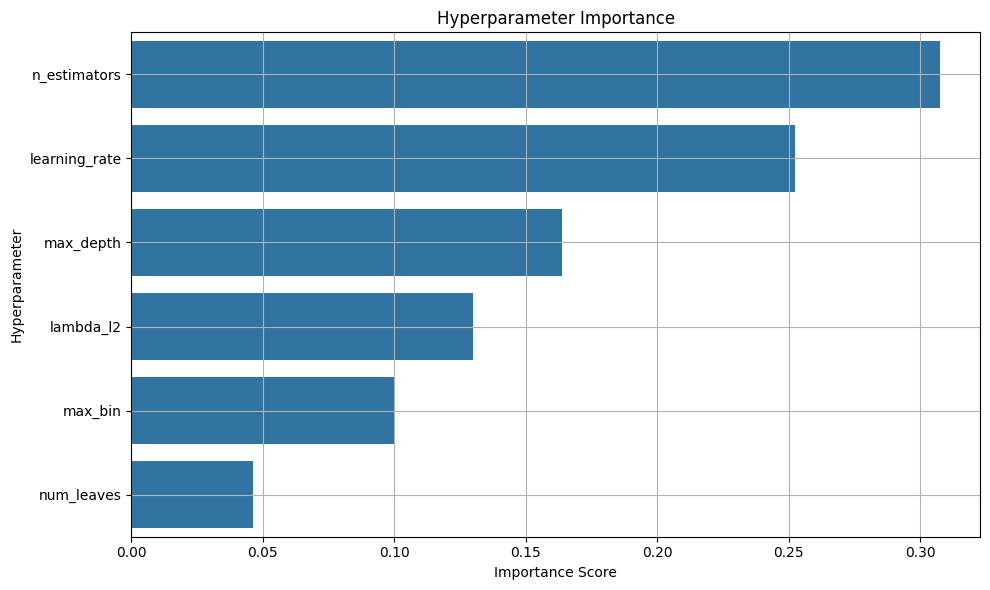

In [9]:
param_importance_dict = optuna.importance.get_param_importances(study)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=list(param_importance_dict.values()), y=list(param_importance_dict.keys()))
plt.xlabel('Importance Score')
plt.ylabel('Hyperparameter')
plt.title('Hyperparameter Importance')
plt.tight_layout()
plt.grid()
plt.show()

By Looking at the plot above we notice which are the most relevant hyperparameters. Next we decide how many of the top parameters we want to compare. We will choose only the 2 most important.

With the plot below we not only see the search space for these 2 most important parameters, but also a sensible range to explore, which we can use to further explore.

C:\Users\jjaramil\AppData\Local\Temp\ipykernel_44628\1164999211.py:3: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_contour(study, params=best2params)


<Axes: title={'center': 'Contour Plot'}, xlabel='learning_rate', ylabel='n_estimators'>

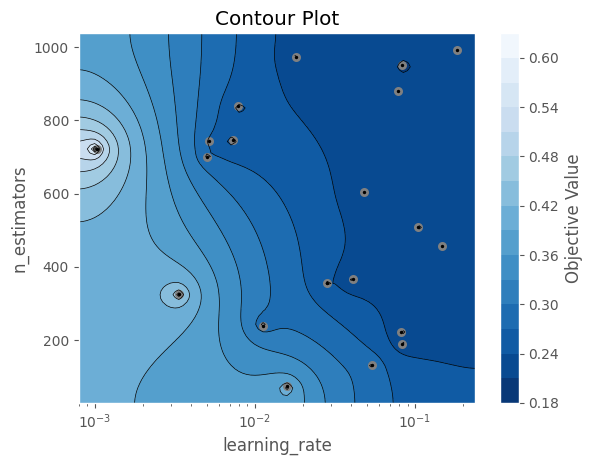

In [10]:
numparamstocompare = 2
best2params = [k for k, v in sorted(param_importance_dict.items(), key=lambda x: x[1])[-numparamstocompare:]]
optuna.visualization.matplotlib.plot_contour(study, params=best2params)

We can leverage these plots to guide new ranges to further explore hyperparameters

# Concurrent studies running to speed up Hyperparam exploration


## Running Concurrent Studies with IRIS DB

To significantly speed up hyperparameter tuning, especially when training on large datasets, you can utilize a pool of concurrent processes running on multiple cores of the same machine or on physically dfferent machines as long as each process runs a study that points to the same underlying storage database (which can be IRIS DB of course). 

While you can execute this by running the Python script provided below (it wont work directly on a jupyter notebook), ensure your InterSystems IRIS instance has a valid license key. The IRIS Community Edition has a built-in limitation on the number of concurrent connections, which may prevent multiple processes from connecting simultaneously. The code below will roughly achieve 60 tials in the same time one single process would finish running 20.

TODO: Check neg is better in scikitlearn convention if this is what makes final best score to to be the best

```python
import os
import dotenv
import optuna
import lightgbm as lgb
import multiprocessing as mp
from sqlalchemy.pool import NullPool
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.datasets import fetch_california_housing

dotenv.load_dotenv()

NUM_WORKERS = min(3, mp.cpu_count())  # CHANGEABLE
NUM_TRIALS_PER_WORKER = 20  # CHANGEABLE
STUDY_NAME = "lightgbm_study_cpuv18"  # CHANGEABLE
BASE_ROOT = 42  # CHANGEABLE

server = os.getenv("IRIS_SERVER")
port = os.getenv("IRIS_PORT")
namespace = os.getenv("IRIS_NAMESPACE")
username = os.getenv("IRIS_USERNAME")
password = os.getenv("IRIS_PASSWORD")
STORAGE_URL = f"iris://{username}:{password}@{server}:{port}/{namespace}"
crossvalstrategy = KFold(n_splits=3, shuffle=True, random_state=BASE_ROOT)

# Load Dataset
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X.columns = [col.replace(" ", "_") for col in X.columns]
y.name = "median_house_value"


def objective(trial):
    param = {
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.001, 0.2, log=True
        ),  # CHANGEABLE
        "max_depth": trial.suggest_int("max_depth", 3, 50),  # CHANGEABLE
        "n_estimators": trial.suggest_int("n_estimators", 50, 1000),  # CHANGEABLE
        "num_leaves": trial.suggest_categorical("num_leaves", [16, 31, 63, 127, 255]),
        "lambda_l2": trial.suggest_float(
            "lambda_l2", 1e-8, 10.0, log=True
        ),  # CHANGEABLE
        "max_bin": trial.suggest_categorical("max_bin", [63, 127, 255]),
    }

    model = lgb.LGBMRegressor(**param, random_state=BASE_ROOT, verbosity=-1, n_jobs=1)

    scores = cross_val_score(
        model,
        X,
        y,
        cv=crossvalstrategy,
        scoring=make_scorer(mean_squared_error),
        n_jobs=1,
    )
    return scores.mean()


def run_worker(worker_id):

    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=make_storage(),
        sampler=optuna.samplers.TPESampler(seed=BASE_ROOT + worker_id),
    )
    study.optimize(
        objective, n_trials=NUM_TRIALS_PER_WORKER, show_progress_bar=False, n_jobs=1
    )
    return worker_id, study.best_value, study.best_params

def make_storage():
    return optuna.storages.RDBStorage(
        url=STORAGE_URL,
        engine_kwargs={"poolclass": NullPool},
    )

if __name__ == "__main__":
    optuna.create_study(
        study_name=STUDY_NAME,
        direction="minimize",
        storage=make_storage(),
        load_if_exists=True,
        sampler=optuna.samplers.TPESampler(seed=BASE_ROOT),
    )

    with mp.Pool(processes=NUM_WORKERS) as pool:
        results = pool.map(run_worker, range(NUM_WORKERS))

    for worker_id, best_value, best_params in results:
        print(
            f"Worker {worker_id} - Best Value: {best_value}, Best Params: {best_params}"
        )

    final_study = optuna.load_study(study_name=STUDY_NAME, storage=make_storage())
    print(
        f"\nOverall Best Value: {final_study.best_value}, Overall Best Params: {final_study.best_params}"
    )
```

Optuna would save run metadata in IRIS for future reference in these tables:

![alt text](../../images/concurrentOptunaStorageinIRIS.png)

## Running Concurrent Studies with MLflow tracking


When you create a MLflow instance using docker (as done in this this [repo](https://github.com/JorgeIvanJH/IRIS_and_MLflow-Continuous-Training-Pipeline)) a postgres db is created to keep track of metrics and parameters, and this can also be leveraged to run parallel studies to tune hyperparameters much faster.

running the script below on a sepparate python script (will not work on a standard jupyter notebook) will allow for parallel hyperparameter tuning with MLflow tracking. It is only neccesary to point to mlflow UI and it would keep track of all the experiemts done in each trial without pointing to the database directly.

```python
import os
import dotenv
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

import lightgbm as lgb
import optuna
import numpy as np

from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import make_scorer, mean_squared_error
from mlflow.models import infer_signature

dotenv.load_dotenv()

BASE_SEED = 42
N_TRIALS = 30

tracking_uri = os.getenv("MLFLOW_TRACKING_URI")
if not tracking_uri:
    raise ValueError("MLFLOW_TRACKING_URI is not set")

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("Hyperparameter Tuning Experiment")

X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X.columns = [col.replace(" ", "_") for col in X.columns]
y.name = "median_house_value"

crossvalstrategy = KFold(n_splits=3, shuffle=True, random_state=BASE_SEED)



def objective(trial):
    param = {
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.2, log=True),  # CHANGEABLE
        "max_depth": trial.suggest_int("max_depth", 3, 50),  # CHANGEABLE
        "n_estimators": trial.suggest_int("n_estimators", 50, 1000),  # CHANGEABLE
        "num_leaves": trial.suggest_categorical("num_leaves", [16, 31, 63, 127, 255]),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),  # CHANGEABLE
        "max_bin": trial.suggest_categorical("max_bin", [63, 127, 255]),
        "random_state": BASE_SEED,
        "verbosity": -1,
        "n_jobs": 1,
    }

    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}") as child_run:

        mlflow.log_params(param)

        model = lgb.LGBMRegressor(**param)

        scores = cross_val_score(model,
                X,
                y,
                cv=crossvalstrategy,
                scoring=make_scorer(mean_squared_error),
                n_jobs=1,
            )
        
        # Log current trial's error metric
        mlflow.log_metrics({"Cross-Validation Error": scores.mean()})

        for fold_idx, score in enumerate(scores):
            mlflow.log_metric(f"Fold_{fold_idx}_Error", score)

        # Make it easy to retrieve the best-performing child run later
        trial.set_user_attr("run_id", child_run.info.run_id)

        return scores.mean()

sampler = optuna.samplers.TPESampler(seed=BASE_SEED)

with mlflow.start_run(run_name="study") as parent_run:
    mlflow.log_params({
        "n_trials": N_TRIALS,
        "cv_n_splits": crossvalstrategy.n_splits,
        "seed": BASE_SEED,
        "dataset": "california_housing",
        "objective_metric": "cv_mse_mean",
    })
    study = optuna.create_study(
        direction="minimize",
        sampler=sampler,
        study_name="lightgbm_california_housing",
    )
    study.optimize(objective, n_trials=N_TRIALS) # CHILD RUNS CREATED HERE

    best_params = study.best_trial.params
    best_value = study.best_value
    best_child_run_id = study.best_trial.user_attrs.get("run_id")

    mlflow.log_params({f"best_{k}": v for k, v in best_params.items()})
    mlflow.log_metric("best_cv_mse", float(best_value))

    if best_child_run_id:
        mlflow.log_param("best_child_run_id", best_child_run_id)

    # Fit and log the actual best model once.
    final_model = lgb.LGBMRegressor(
        **best_params,
        random_state=BASE_SEED,
        verbosity=-1,
        n_jobs=1,
    )
    final_model.fit(X, y)

    signature = infer_signature(X, final_model.predict(X))

    mlflow.lightgbm.log_model(
        sk_model=final_model,
        name="best_model",
        signature=signature,
        input_example=X.head(5),
    )
```